In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_squared_error
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import f1_score
import spacy
import gensim
import nltk
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
leetcode_questions_df = pd.read_csv('/content/drive/MyDrive/thesis/leetcode/part2 feature-creation/code_features_extracts.csv')
leetcode_questions_df['num_of_contest'] = leetcode_questions_df.num_of_contest.astype('category')
leetcode_questions_df['question_number'] = leetcode_questions_df.question_number.astype('category')
leetcode_questions_df['finish_time'] = pd.to_datetime(leetcode_questions_df['finish_time'], format='%H:%M:%S').astype(int)
leetcode_questions_df['question_finish_time'] = pd.to_datetime(leetcode_questions_df['question_finish_time'], format='%H:%M:%S').astype(int)

leetcode_questions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61834 entries, 0 to 61833
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   username                     61834 non-null  object  
 1   country                      61834 non-null  object  
 2   contest_url                  61834 non-null  object  
 3   num_of_contest               61834 non-null  category
 4   finish_time                  61834 non-null  int64   
 5   is_weekly                    61834 non-null  bool    
 6   rank                         61834 non-null  int64   
 7   score                        61834 non-null  int64   
 8   user_global_rank             61834 non-null  float64 
 9   question_number              61834 non-null  category
 10  question_language            61834 non-null  object  
 11  question_code                61834 non-null  object  
 12  question_finish_time         61834 non-null  int64   
 13  n

In [4]:
leetcode_questions_df.head()

,username,country,contest_url,num_of_contest,finish_time,is_weekly,rank,score,user_global_rank,question_number,...,variables_count,function_count,loop_count,condition_count,single_line_comment_density,multiline_comment_density,function_density,loop_density,condition_density,comment_tokens_density
0,fmota,Brazil,https://leetcode.com/contest/weekly-contest-36...,367,-2208988044000000000,True,2,17,486427.0,1,...,12,1,2,1,0.000000,0.0,0.045455,0.090909,0.045455,0.0
1,nicholask_17,Hong Kong,https://leetcode.com/contest/weekly-contest-36...,367,-2208988018000000000,True,3,17,27684.0,1,...,18,1,2,6,0.000000,0.0,0.032258,0.064516,0.193548,0.0
2,skywalkert,China,https://leetcode.com/contest/weekly-contest-36...,367,-2208987996000000000,True,4,17,16.0,1,...,17,1,1,2,0.000000,0.0,0.037037,0.037037,0.074074,0.0
3,hank55663,Taiwan,https://leetcode.com/contest/weekly-contest-36...,367,-2208987929000000000,True,7,17,6234.0,1,...,12,1,1,5,0.037037,0.0,0.040000,0.040000,0.200000,0.2
4,DimmyT,Kazakhstan,https://leetcode.com/contest/weekly-contest-36...,367,-2208987916000000000,True,8,17,702585.0,1,...,10,1,2,1,0.000000,0.0,0.052632,0.105263,0.052632,0.0


In [5]:
leetcode_questions_df = leetcode_questions_df[leetcode_questions_df['question_language'] == 'C++']

In [6]:
leetcode_questions_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 39431 entries, 0 to 61831
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   username                     39431 non-null  object  
 1   country                      39431 non-null  object  
 2   contest_url                  39431 non-null  object  
 3   num_of_contest               39431 non-null  category
 4   finish_time                  39431 non-null  int64   
 5   is_weekly                    39431 non-null  bool    
 6   rank                         39431 non-null  int64   
 7   score                        39431 non-null  int64   
 8   user_global_rank             39431 non-null  float64 
 9   question_number              39431 non-null  category
 10  question_language            39431 non-null  object  
 11  question_code                39431 non-null  object  
 12  question_finish_time         39431 non-null  int64   
 13  number

In [7]:
leetcode_questions_df.country.value_counts()

country
India            25460
United States     3850
Taiwan            2264
China             1351
Canada             820
                 ...  
Greece               3
Nigeria              3
Chad                 3
Ethiopia             1
Spain                1
Name: count, Length: 74, dtype: int64

<Axes: ylabel='Frequency'>

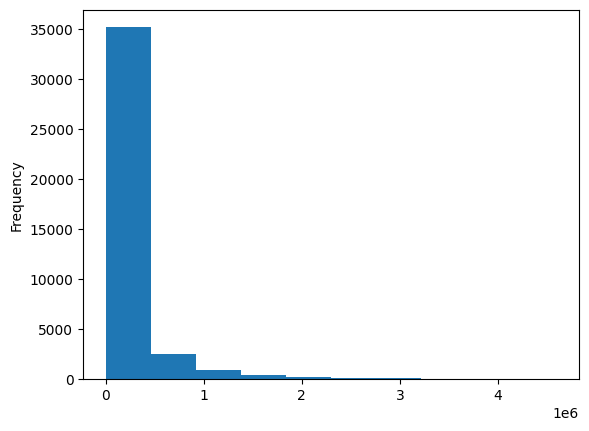

In [8]:
leetcode_questions_df['user_global_rank'].plot.hist()

In [9]:
leetcode_questions_df['user_global_rank'].max(), leetcode_questions_df['user_global_rank'].mean(), leetcode_questions_df['user_global_rank'].median()

(4598201.0, 175567.15924019172, 41317.0)

<Axes: ylabel='Frequency'>

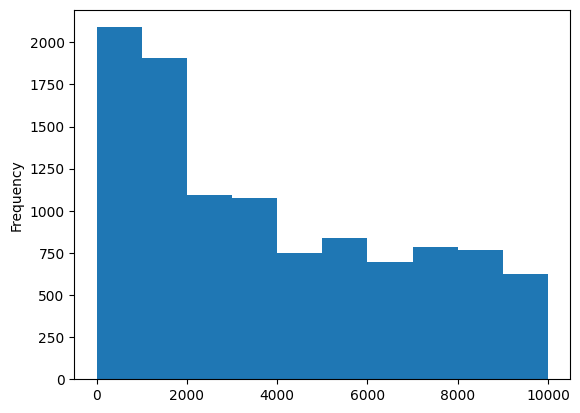

In [10]:
leetcode_questions_df = leetcode_questions_df[leetcode_questions_df['user_global_rank'] < 10000]

leetcode_questions_df['user_global_rank'].plot.hist()

In [11]:
leetcode_questions_df = leetcode_questions_df[leetcode_questions_df.groupby('country')['country'].transform('size') > 100]
leetcode_questions_df['country'] = leetcode_questions_df.country.astype('category')

<ipython-input-11-22d56a376d39>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  leetcode_questions_df['country'] = leetcode_questions_df.country.astype('category')


In [12]:
X=leetcode_questions_df.drop('user_global_rank',axis=1)
Y=leetcode_questions_df['user_global_rank']

In [13]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9873 entries, 2 to 61829
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   username                     9873 non-null   object  
 1   country                      9873 non-null   category
 2   contest_url                  9873 non-null   object  
 3   num_of_contest               9873 non-null   category
 4   finish_time                  9873 non-null   int64   
 5   is_weekly                    9873 non-null   bool    
 6   rank                         9873 non-null   int64   
 7   score                        9873 non-null   int64   
 8   question_number              9873 non-null   category
 9   question_language            9873 non-null   object  
 10  question_code                9873 non-null   object  
 11  question_finish_time         9873 non-null   int64   
 12  number_of_lines              9873 non-null   int64   
 13  names_s

# Non text features

In [14]:
X_nontext=X[['country', 'num_of_contest',
            'finish_time', 'is_weekly', 'score', 'username',
            'question_number', 'question_finish_time', 'number_of_lines',
            'token_count', 'variables_count', 'function_count', 'loop_count',
            'condition_count', 'single_line_comment_density',
            'multiline_comment_density', 'function_density', 'loop_density',
            'condition_density', 'comment_tokens_density']]
X_nontext.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9873 entries, 2 to 61829
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   country                      9873 non-null   category
 1   num_of_contest               9873 non-null   category
 2   finish_time                  9873 non-null   int64   
 3   is_weekly                    9873 non-null   bool    
 4   score                        9873 non-null   int64   
 5   username                     9873 non-null   object  
 6   question_number              9873 non-null   category
 7   question_finish_time         9873 non-null   int64   
 8   number_of_lines              9873 non-null   int64   
 9   token_count                  9873 non-null   int64   
 10  variables_count              9873 non-null   int64   
 11  function_count               9873 non-null   int64   
 12  loop_count                   9873 non-null   int64   
 13  conditi

In [16]:
X_train_nontext = X_nontext.iloc[:0]
X_test_nontext = X_nontext.iloc[:0]
y_train = pd.Series()
y_test = pd.Series()

unique_countries = X_nontext.country.unique()

for country in unique_countries:
    country_data = X_nontext[X_nontext.country == country]

    splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)

    groups = country_data['username'].values

    for train_indices, test_indices in splitter.split(X.loc[country_data.index], Y.loc[country_data.index], groups=groups):
        X_train_nontext = X_train_nontext._append(country_data.iloc[train_indices], ignore_index = True)
        X_test_nontext = X_test_nontext._append(country_data.iloc[test_indices], ignore_index = True)
        y_train = pd.concat([y_train, Y.loc[country_data.index[train_indices]]], ignore_index=True)
        y_test = pd.concat([y_test, Y.loc[country_data.index[test_indices]]], ignore_index=True)

X_train_nontext.drop('username', axis=1, inplace=True)
X_test_nontext.drop('username', axis=1, inplace=True)

In [17]:
#handle categorical columns

categorical = X_train_nontext.dtypes == 'category'

preprocess = make_column_transformer(
    (StandardScaler(), ~categorical),
    (OneHotEncoder(drop='first',handle_unknown='ignore'), categorical))

baseline_model = Pipeline([('encoder_scaler',preprocess),
                           ('regression',Ridge())])

In [18]:
param_grid = [{'regression__alpha': np.logspace(0,3,16)}]
ridge_cv= GridSearchCV(baseline_model, param_grid,cv=5,return_train_score=True)
ridge_cv.fit(X_train_nontext, y_train)
print("nontext grid ridge train score ",ridge_cv.score(X_train_nontext, y_train))
print("nontext grid ridge test score ",ridge_cv.score(X_test_nontext, y_test))
print("nontext Ridge regression train mse score ",mean_squared_error(y_train,ridge_cv.predict(X_train_nontext)))
print("nontext Ridge regression test mse score ",mean_squared_error(y_test,ridge_cv.predict(X_test_nontext)))
ridge_cv.best_params_

/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:202: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:202: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:202: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:202: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:202: UserWarning: Found unknown categ

nontext grid ridge train score  0.21252271398607503
nontext grid ridge test score  0.3036376318041468
nontext Ridge regression train mse score  6819663.770754784
nontext Ridge regression test mse score  6364410.390144399


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:202: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


{'regression__alpha': 63.09573444801933}

# simple BOW

In [21]:
X_text=X[['username','question_code']]
X_train_text = X_text.iloc[:0]
X_test_text = X_text.iloc[:0]
y_train = pd.Series()
y_test = pd.Series()

unique_countries = X_nontext.country.unique()

for country in unique_countries:
    country_data = X_nontext[X_nontext.country == country]

    splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)

    groups = country_data['username'].values

    for train_indices, test_indices in splitter.split(X.loc[country_data.index], Y.loc[country_data.index], groups=groups):
        X_train_text = X_train_text._append(X_text.loc[country_data.index[train_indices]], ignore_index = True)
        X_test_text = X_test_text._append(X_text.loc[country_data.index[test_indices]], ignore_index = True)
        y_train = pd.concat([y_train, Y.loc[country_data.index[train_indices]]], ignore_index=True)
        y_test = pd.concat([y_test, Y.loc[country_data.index[test_indices]]], ignore_index=True)

X_train_text = X_train_text.question_code
X_test_text = X_test_text.question_code

In [22]:
#create BOW
custom_token_pattern = r'\b[A-Za-z_]\w*\b'

# Initialize CountVectorizer with the custom token pattern
vect = CountVectorizer(stop_words='english', min_df=50, token_pattern=custom_token_pattern)
X_train_simple=vect.fit_transform(X_train_text)
X_test_simple=vect.transform(X_test_text)
print(vect.get_feature_names_out())

['_' '__builtin_popcount' '__builtin_popcountll' '__linux__' '__typeof'
 '_c' '_f1' '_f2' '_f3' '_get' '_id' '_if' '_in' '_init' '_int' '_len'
 '_len2' '_madd' '_max' '_min' '_mm' '_oo' '_p' '_rep' '_sort' '_swap'
 '_this' '_un' '_vvi' '_vvl' '_vvvi' '_x' '_xor' '_y' '_y_default' 'abs'
 'accumulate' 'add' 'adj' 'ai' 'ans' 'ans1' 'answer' 'aresimilar' 'args'
 'arr' 'arr1' 'arr2' 'array' 'assert' 'author' 'auto' 'b' 'base'
 'beautifulindices' 'beautifulsubstrings' 'begin' 'bfind' 'bin1' 'bit'
 'bitcnt' 'bits' 'bool' 'break' 'c' 'cansortarray' 'ch' 'char' 'check'
 'child' 'chmax' 'chmin' 'chsum' 'cin' 'class' 'clear' 'cmp' 'cnt' 'col'
 'compiled' 'const' 'constexpr' 'constructproductmatrix' 'continue' 'cost'
 'count' 'countmatchingsubarrays' 'countofpairs' 'countprefixsuffixpairs'
 'counts' 'countsubarrays' 'countsubmatrices' 'counttesteddevices' 'cout'
 'cur' 'curr' 'd' 'data' 'dcmp' 'dd' 'define' 'dfs' 'diff' 'dirs' 'dist'
 'distributecandies' 'dividearray' 'double' 'dp' 'dx' 'dy' 'e'
 

In [23]:
ridge = Ridge().fit(X_train_simple, y_train)
print("simple BOW Ridge train score ",ridge.score(X_train_simple, y_train))
print("simple BOW Ridge test score ",ridge.score(X_test_simple, y_test))
print("simple BOW Ridge train mse score ",mean_squared_error(y_train,ridge.predict(X_train_simple)))
print("simple BOW Ridge test mse score ",mean_squared_error(y_test,ridge.predict(X_test_simple)))

simple BOW Ridge train score  0.20884881204876582
simple BOW Ridge test score  -1.0043913316561541
simple BOW Ridge train mse score  6851480.276937453
simple BOW Ridge test mse score  18319153.35999307


In [24]:
def plot_important_features(coef, feature_names, top_n=20, ax=None, rotation=60):
    if ax is None:
         ax = plt.gca()
    inds = np.argsort(coef)
    low = inds[:top_n]
    high = inds[-top_n:]
    important = np.hstack([low, high])
    myrange = range(len(important))
    colors = ['red'] * top_n + ['blue'] * top_n
    ax.bar(myrange, coef[important], color=colors)
    ax.set_xticks(myrange)
    ax.set_xticklabels(feature_names[important], rotation=rotation, ha="right")
    ax.set_xlim(-.7, 2 * top_n)
    ax.set_frame_on(False)

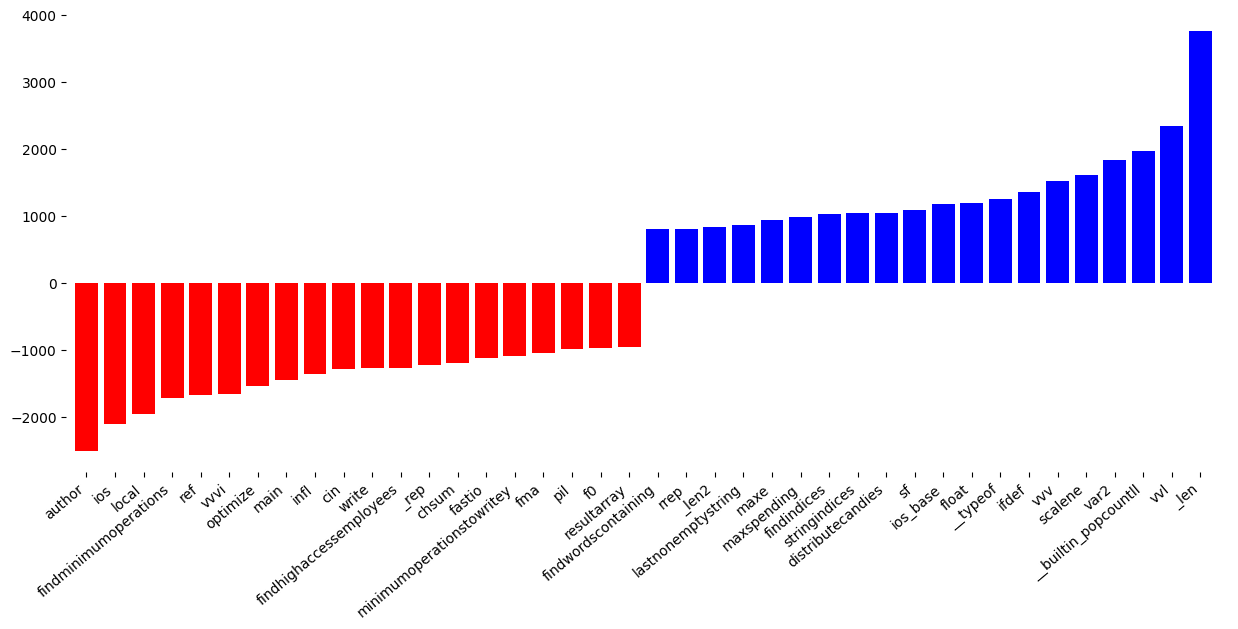

In [25]:
plt.figure(figsize=(15, 6))
plot_important_features(ridge.coef_.ravel(), vect.get_feature_names_out(), top_n=20, rotation=40)
ax = plt.gca()
plt.show()

# n-grams tf-idf

In [26]:
wordnet_lem = WordNetLemmatizer()

X_train_lemma=X_train_text.apply(wordnet_lem.lemmatize)
X_test_lemma=X_test_text.apply(wordnet_lem.lemmatize)

In [27]:
tfidf_pipeline = make_pipeline(CountVectorizer(stop_words='english',ngram_range=(2,10),min_df=50),
                      Normalizer(),
                      TfidfTransformer(),
                      Ridge(random_state=0),memory="cache_folder")

In [28]:
param_grid = [{
    'countvectorizer__ngram_range':[(2, 5), (5,9), (2,10)],
    'ridge__alpha':np.logspace(-2,2,5)}]

ridge_cv= GridSearchCV(tfidf_pipeline, param_grid,cv=5,return_train_score=True)

ridge_cv.fit(X_train_lemma, y_train)

print("n-grams grid ridge train score ",ridge_cv.score(X_train_lemma, y_train))
print("n-grams grid ridge test score ",ridge_cv.score(X_test_lemma, y_test))
print("n-grams Ridge train mse score ",mean_squared_error(y_train,ridge_cv.predict(X_train_lemma)))
print("n-grams Ridge test mse score ",mean_squared_error(y_test,ridge_cv.predict(X_test_lemma)))
ridge_cv.best_params_

n-grams grid ridge train score  0.21121518073887258
n-grams grid ridge test score  -0.0060819972164738445
n-grams Ridge train mse score  6830987.192107215
n-grams Ridge test mse score  9195095.84214187


{'countvectorizer__ngram_range': (2, 5), 'ridge__alpha': 10.0}

In [29]:
results = pd.DataFrame(ridge_cv.cv_results_)
results.head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_countvectorizer__ngram_range,param_ridge__alpha,params,split0_test_score,split1_test_score,split2_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,5.392225,0.687083,0.470193,0.205570,"(2, 5)",0.01,"{'countvectorizer__ngram_range': (2, 5), 'ridg...",-0.776658,-0.292335,-0.383737,...,-0.455038,0.166960,14,0.409441,0.449557,0.482464,0.449360,0.415242,0.441213,0.026539
1,1.828973,0.476879,0.519419,0.281551,"(2, 5)",0.1,"{'countvectorizer__ngram_range': (2, 5), 'ridg...",-0.681708,-0.109108,-0.267562,...,-0.286787,0.205864,10,0.386258,0.410891,0.441728,0.411245,0.379263,0.405877,0.022056
2,1.482811,0.366822,0.394397,0.159534,"(2, 5)",1.0,"{'countvectorizer__ngram_range': (2, 5), 'ridg...",-0.631624,-0.012505,-0.183460,...,-0.199546,0.225369,5,0.326659,0.332954,0.357900,0.330854,0.301960,0.330065,0.017806
3,1.615836,0.370624,0.537812,0.270067,"(2, 5)",10.0,"{'countvectorizer__ngram_range': (2, 5), 'ridg...",-0.615505,0.011838,-0.130723,...,-0.163951,0.235748,1,0.216610,0.211289,0.227567,0.209263,0.185598,0.210065,0.013784
4,1.338354,0.390853,0.390244,0.145797,"(2, 5)",100.0,"{'countvectorizer__ngram_range': (2, 5), 'ridg...",-0.634809,-0.026555,-0.115135,...,-0.188205,0.230183,3,0.082982,0.077149,0.083222,0.077538,0.067988,0.077776,0.005532
5,8.761812,0.446353,0.728343,0.460938,"(5, 9)",0.01,"{'countvectorizer__ngram_range': (5, 9), 'ridg...",-0.946898,-0.054138,-0.146000,...,-0.325426,0.319823,13,0.135085,0.132218,0.145454,0.147405,0.124214,0.136875,0.008599
6,2.868834,0.801304,0.677171,0.467667,"(5, 9)",0.1,"{'countvectorizer__ngram_range': (5, 9), 'ridg...",-0.862695,-0.043130,-0.145197,...,-0.299150,0.291829,12,0.132228,0.128247,0.142376,0.144158,0.121643,0.133730,0.008508
7,2.718797,0.625111,0.601398,0.404821,"(5, 9)",1.0,"{'countvectorizer__ngram_range': (5, 9), 'ridg...",-0.718376,-0.044478,-0.139614,...,-0.259066,0.240803,9,0.123555,0.116272,0.130596,0.133438,0.111236,0.123019,0.008374
8,2.533805,0.487122,0.496169,0.177581,"(5, 9)",10.0,"{'countvectorizer__ngram_range': (5, 9), 'ridg...",-0.679829,-0.043239,-0.124793,...,-0.229150,0.235572,8,0.101910,0.091550,0.099547,0.105163,0.086477,0.096929,0.006894
9,2.818823,0.688541,0.551502,0.189345,"(5, 9)",100.0,"{'countvectorizer__ngram_range': (5, 9), 'ridg...",-0.666036,-0.046155,-0.114398,...,-0.212135,0.234262,7,0.053948,0.045170,0.046552,0.050674,0.041910,0.047651,0.004222


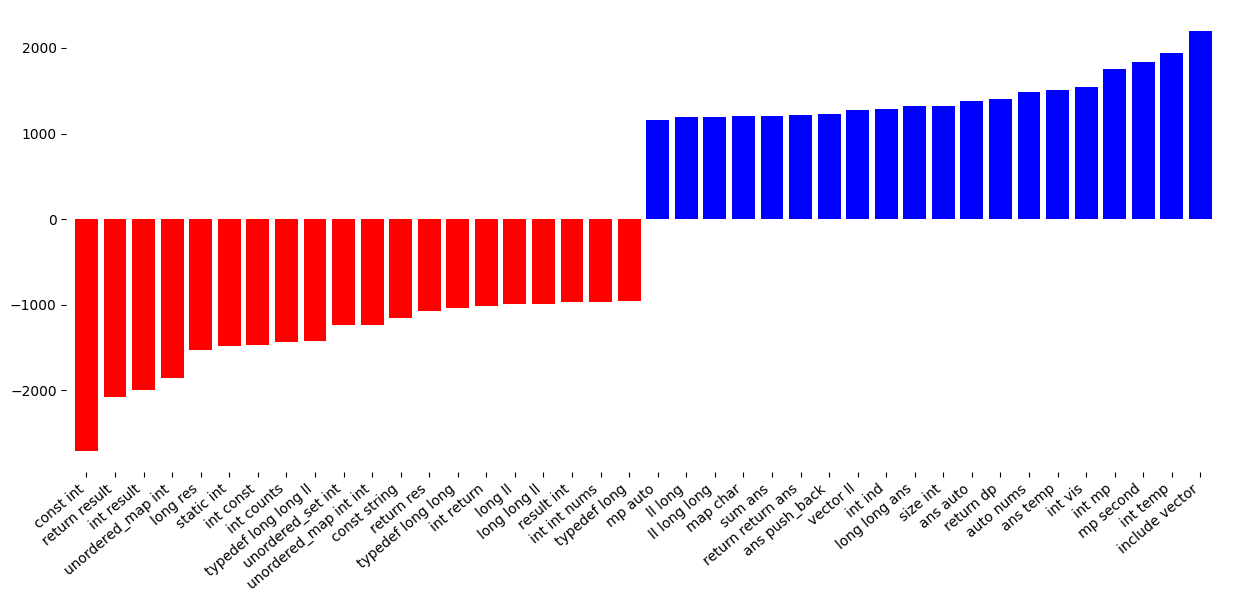

In [30]:
plt.figure(figsize=(15, 6))
plot_important_features(ridge_cv.best_estimator_.named_steps.ridge.coef_.ravel(), ridge_cv.best_estimator_[:-1].get_feature_names_out(), top_n=20, rotation=40)
ax = plt.gca()
plt.show()

#Pretrained Work Vectors

In [31]:
%%python -m spacy download en_core_web_lg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 587.7/587.7 MB 2.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [32]:
nlp = spacy.load("en_core_web_lg", disable=["tagger", "parser", "ner","lemmatizer"])
docs_train = [nlp(d).vector for d in X_train_text]
docs_test = [nlp(d).vector for d in X_test_text]

In [33]:
X_train_w2v = np.vstack(docs_train)
X_test_w2v = np.vstack(docs_test)
X_train_w2v.shape, X_test_w2v.shape

((6980, 300), (2893, 300))

In [34]:
param_grid = [{'alpha':np.logspace(-2,2,20)}]
ridge_cv= GridSearchCV(Ridge(random_state=0), param_grid,cv=5)
ridge_cv.fit(X_train_w2v, y_train)
print("spacy grid ridge train score ",ridge_cv.score(X_train_w2v, y_train))
print("spacy grid ridge test score ",ridge_cv.score(X_test_w2v, y_test))
print("spacy Ridge Regression train mse score ",mean_squared_error(y_train,ridge_cv.predict(X_train_w2v)))
print("spacy Ridge Regression test mse score ",mean_squared_error(y_test,ridge_cv.predict(X_test_w2v)))
ridge_cv.best_params_

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=3.98268e-08): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=3.90025e-08): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=4.49221e-08): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=4.20356e-08): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarnin

spacy grid ridge train score  0.1849621756267067
spacy grid ridge test score  0.026215452548171037
spacy Ridge Regression train mse score  7058341.899368842
spacy Ridge Regression test mse score  8899912.997339636


{'alpha': 61.584821106602604}

In [35]:
def read_corpus(text, tokens_only=False):
    for i, line in enumerate(text):
        tokens = gensim.utils.simple_preprocess(line)
        if tokens_only:
            yield tokens
        else:
        # For training data, add tags
            yield gensim.models.doc2vec.TaggedDocument(tokens, [i])

train_corpus = list(read_corpus(X_train_text))
test_corpus = list(read_corpus(X_test_text, tokens_only=True))

In [36]:
model = gensim.models.doc2vec.Doc2Vec(vector_size=50, min_count=2)
model.build_vocab(train_corpus)
model.train(train_corpus, total_examples=model.corpus_count, epochs=55)

In [37]:
vectors = [model.infer_vector(train_corpus[doc_id].words) for doc_id in range(len(train_corpus))]
X_train_doc2vec = np.vstack(vectors)

test_vectors = [model.infer_vector(test_corpus[doc_id]) for doc_id in range(len(test_corpus))]
X_test_doc2vec = np.vstack(test_vectors)

X_train_doc2vec.shape , X_test_doc2vec.shape

((6980, 50), (2893, 50))

In [38]:
param_grid = [{'alpha':np.logspace(-2,2,20)}]
ridge_cv= GridSearchCV(Ridge(random_state=0), param_grid,cv=5)
ridge_cv.fit(X_train_doc2vec, y_train)
print("gensim doc2vec grid ridge train score ",ridge_cv.score(X_train_doc2vec, y_train))
print("gensim doc2vec grid ridge test score ",ridge_cv.score(X_test_doc2vec, y_test))
print("gensim doc2vec Ridge train mse score ",mean_squared_error(y_train,ridge_cv.predict(X_train_doc2vec)))
print("gensim doc2vec Ridge test mse score ",mean_squared_error(y_test,ridge_cv.predict(X_test_doc2vec)))
ridge_cv.best_params_

gensim doc2vec grid ridge train score  0.08380724325145883
gensim doc2vec grid ridge test score  -0.06517144054535784
gensim doc2vec Ridge train mse score  7934357.80459513
gensim doc2vec Ridge test mse score  9735144.363207884


{'alpha': 100.0}

# Combine Text and non text features

In [39]:
X_train_combined=pd.concat([X_train_lemma,X_train_nontext],axis=1)

X_test_combined=pd.concat([X_test_lemma,X_test_nontext],axis=1)

X_train_combined.head(5)

,question_code,country,num_of_contest,finish_time,is_weekly,score,question_number,question_finish_time,number_of_lines,token_count,variables_count,function_count,loop_count,condition_count,single_line_comment_density,multiline_comment_density,function_density,loop_density,condition_density,comment_tokens_density
0,class Solution {\npublic:\n vector<int> fin...,China,367,-2208987996000000000,True,17,1,-2208988524000000000,17,27,17,1,1,2,0.000000,0.0,0.037037,0.037037,0.074074,0.000000
1,class Solution {\npublic:\n vector<int> fin...,China,367,-2208987370000000000,True,17,1,-2208988686000000000,15,19,10,1,2,1,0.000000,0.0,0.052632,0.105263,0.052632,0.000000
2,class Solution {\npublic:\n vector<int> fin...,China,367,-2208987318000000000,True,17,1,-2208988375000000000,19,21,11,1,1,5,0.000000,0.0,0.047619,0.047619,0.238095,0.000000
3,class Solution {\npublic:\n vector<int> fin...,China,367,-2208985507000000000,True,17,1,-2208988553000000000,16,19,10,1,2,2,0.000000,0.0,0.052632,0.105263,0.105263,0.000000
4,typedef vector<TreeNode*> vt;\ntypedef TreeNod...,China,367,-2208983320000000000,True,17,1,-2208988634000000000,269,247,185,124,11,39,0.011194,0.0,0.502024,0.044534,0.157895,0.040486


In [40]:
X_train_combined.dtypes

question_code                    object
country                        category
num_of_contest                 category
finish_time                       int64
is_weekly                          bool
score                             int64
question_number                category
question_finish_time              int64
number_of_lines                   int64
token_count                       int64
variables_count                   int64
function_count                    int64
loop_count                        int64
condition_count                   int64
single_line_comment_density     float64
multiline_comment_density       float64
function_density                float64
loop_density                    float64
condition_density               float64
comment_tokens_density          float64
dtype: object

In [41]:
categorical = X_train_combined.dtypes == 'category'

tfidf = make_pipeline(CountVectorizer(stop_words='english', ngram_range=(2,10), min_df=50, token_pattern=custom_token_pattern),
                      Normalizer(),
                      TfidfTransformer(),memory="cache_folder")

make_column_transformer(
    (StandardScaler(), ~categorical),
    (OneHotEncoder(drop='first',handle_unknown='ignore'), categorical))

preprocessor_combined = make_column_transformer((tfidf, 'question_code'),
                                                (StandardScaler(), ~categorical & (X_train_combined.dtypes != object)),
                                                (OneHotEncoder(drop='first',handle_unknown='ignore'), categorical))

combine_model = Pipeline([('transformer',preprocessor_combined),
                           ('regression',Ridge(random_state=0))])

In [42]:
scores = cross_val_score(combine_model, X_train_combined, y_train, cv=5)
print("baseline model score: ",np.mean(scores))

/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:202: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:202: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:202: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


baseline model score:  -0.044936776491146066


In [43]:
param_grid = [{
    'transformer__pipeline__countvectorizer__ngram_range':[(2, 5), (3, 6), (4,8)],
    'regression__alpha':np.logspace(-2,2,10)}]

ridge_cv= GridSearchCV(combine_model, param_grid,cv=5,return_train_score=True)

ridge_cv.fit(X_train_combined, y_train)

print("combined grid ridge train score ",ridge_cv.score(X_train_combined, y_train))
print("combined grid ridge test score ",ridge_cv.score(X_test_combined, y_test))
print("combined Ridge train mse score ",mean_squared_error(y_train,ridge_cv.predict(X_train_combined)))
print("combined Ridge test mse score ",mean_squared_error(y_test,ridge_cv.predict(X_test_combined)))
ridge_cv.best_params_

/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:202: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:202: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:202: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:202: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:202: UserWarning: Found unknown categ

combined grid ridge train score  0.4435852873937768
combined grid ridge test score  0.17158446574790165
combined Ridge train mse score  4818629.469661295
combined Ridge test mse score  7571311.538862785


{'regression__alpha': 1.6681005372000592,
 'transformer__pipeline__countvectorizer__ngram_range': (2, 5)}